# OVRO-LWA source metacatalog

Identify sources in OVRO-LWA wide-field FITS images with **PyBDSF**, then fuse
per-image catalogs into a **metacatalog** with one entry per unique sky position.

Pipeline (library: `lwa_catalog.create` + Parquet I/O):

1. **Discover** FITS under `FITS_ROOT` (LST hour + color band from filenames).
2. **Detect** sources per image (`detect_sources`).
3. **LST merge** within each band (`merge_lst_metacatalog`).
4. **Band merge** sequential Full→Blue→Green→Red (`build_global_metacatalog`).

Catalogs are written as **Parquet** under `OUTPUT_DIR` via `CatalogLayout`.
Set `REUSE_CACHED_CATALOGS = True` to skip PyBDSF / LST merge when caches exist.
Set `MIGRATE_LEGACY_CSV = True` once to convert old CSV/FITS catalog trees.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, migrate_output_dir
from lwa_catalog.create import (
    build_global_metacatalog,
    detect_sources,
    discover_fits_files,
    discovered_slots,
    lst_hours_from_discovery,
    merge_lst_metacatalog,
)
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_all_lst_merged,
    read_sources_catalog,
    sources_cache_complete,
    write_lst_merged,
    write_metacatalog,
    write_sources_catalog,
)

# --- user configuration ---------------------------------------------------
#FITS_ROOT = Path("/fast/claw")  # directory containing FITS images (searched recursively)
FITS_ROOT = Path("/lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827")
# Glob(s) relative to FITS_ROOT (rglob). Default: all .fits. Examples:
#   "I_*_deep_Taper_R0_*.fits"  or  ("*.fits", "*_LST*h_*.fits")
#FITS_GLOB: str | tuple[str, ...] = "*.fits"
FITS_GLOB = "??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits"
OUTPUT_DIR = Path("/fast/claw/metacatalog_coadd2")  # Parquet catalog tree

# PyBDSF detection parameters
BDSF_KW = dict(
    thresh="hard",
    thresh_isl=5.0,
    thresh_pix=3.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=16,
)

# Optional subset of LST hour bins (e.g. ["01h", "02h"]). None = all discovered.
LST_HOURS_OVERRIDE: list[str] | None = None
ASSOC_BANDS = ("Blue", "Green", "Red")

# When True, skip PyBDSF / LST merge if matching Parquet files already exist
REUSE_CACHED_CATALOGS = True

# One-time CSV/FITS → Parquet migration (no-op if only Parquet is present)
MIGRATE_LEGACY_CSV = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)

if MIGRATE_LEGACY_CSV:
    migrated = migrate_output_dir(layout)
    print(f"Migrated {len(migrated)} legacy catalog file(s) under {OUTPUT_DIR}")


## Filename parsing

Discover FITS under `FITS_ROOT` and parse LST hour / color band from filenames
(`lwa_catalog.create.discover`). Band names are defined as notebook constants below.


In [2]:
# Explicit catalog constants (notebook-local; passed into library APIs below)
COLOR_BANDS = ("Full", "Blue", "Green", "Red")


In [3]:
_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
fits_files = discover_fits_files(FITS_ROOT, patterns=_fits_patterns)
_discovered_lst_hours = lst_hours_from_discovery(fits_files)
LST_HOURS = list(LST_HOURS_OVERRIDE) if LST_HOURS_OVERRIDE is not None else _discovered_lst_hours
fits_by_slot = discovered_slots(fits_files)
summary = pd.DataFrame(
    {
        "path": [m.path.name for m in fits_files],
        "lst_hour": [m.lst_hour for m in fits_files],
        "band": [m.band for m in fits_files],
        "time_key": [m.time_key for m in fits_files],
    }
)
print(f"Found {len(fits_files)} FITS files under {FITS_ROOT} matching {list(_fits_patterns)}")
print(
    f"LST hours from discovery ({len(_discovered_lst_hours)}): "
    f"{', '.join(_discovered_lst_hours)}"
)
if LST_HOURS_OVERRIDE is not None:
    print(f"LST hours in use (override): {', '.join(LST_HOURS)}")
else:
    print(f"LST hours in use (all discovered): {', '.join(LST_HOURS)}")
summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Found 93 FITS files under /lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827 matching ['??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits']
LST hours from discovery (24): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h, 23h
LST hours in use (all discovered): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h, 23h


,path,lst_hour,band,time_key
0,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,00h,Blue,None
1,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,00h,Full,None
2,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,00h,Green,None
3,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,00h,Red,None
4,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,01h,Blue,None
...,...,...,...,...
88,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,22h,Blue,None
89,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,22h,Full,None
90,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,22h,Green,None
91,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,22h,Red,None


## PyBDSF source detection

Detect sources per image with PyBDSF (`lwa_catalog.create.detect`).
`GAUL_COLUMNS` and `BDSF_KW` are notebook-local; cache helpers wrap Parquet I/O.


In [4]:
GAUL_COLUMNS = [
    "RA",
    "DEC",
    "E_RA",
    "E_DEC",
    "Total_flux",
    "E_Total_flux",
    "Peak_flux",
    "E_Peak_flux",
    "Maj",
    "E_Maj",
    "Min",
    "E_Min",
    "PA",
    "E_PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
    "S_Code",
    "Gaus_id",
    "Isl_id",
    "Source_id",
    "Resid_Isl_rms",
    "Resid_Isl_mean",
]


def all_sources_cached() -> bool:
    """True when every discovered (lst, band) slot has a sources Parquet file."""
    return sources_cache_complete(layout, sorted(fits_by_slot))


def all_lst_merged_cached() -> bool:
    """True when every color band has an LST-merged Parquet file."""
    return lst_merged_cache_complete(layout, COLOR_BANDS)


def load_sources_catalog(lst_hour: str, band: str) -> pd.DataFrame:
    """Load a per-image sources Parquet catalog, backfilling beam from the FITS image."""
    meta = fits_by_slot[(lst_hour, band)]
    return read_sources_catalog(layout, lst_hour, band, fits_path=meta.path)


def load_per_image_catalogs_from_disk() -> dict[tuple[str, str], pd.DataFrame]:
    """Load all per-image catalogs from OUTPUT_DIR when every slot is cached."""
    catalogs: dict[tuple[str, str], pd.DataFrame] = {}
    for lst_hour, band in sorted(fits_by_slot):
        catalogs[(lst_hour, band)] = load_sources_catalog(lst_hour, band)
    return catalogs


def load_lst_merged_from_disk() -> dict[str, pd.DataFrame]:
    """Load LST-merged per-band catalogs from OUTPUT_DIR."""
    return read_all_lst_merged(layout, COLOR_BANDS)


In [5]:
per_image_catalogs: dict[tuple[str, str], pd.DataFrame] = {}

for (lst_hour, band), meta in sorted(fits_by_slot.items()):
    key = (lst_hour, band)
    out_path = layout.sources(lst_hour, band)

    if REUSE_CACHED_CATALOGS and out_path.is_file():
        catalog = load_sources_catalog(lst_hour, band)
        per_image_catalogs[key] = catalog
        print(f"Cached {key}: {len(catalog)} sources <- {out_path.name}")
        continue

    catalog = detect_sources(meta, bdsf_kw=BDSF_KW, gaul_columns=GAUL_COLUMNS)
    per_image_catalogs[key] = catalog
    write_sources_catalog(catalog, layout, lst_hour, band)
    print(f"Detected {key}: {len(catalog)} sources -> {out_path.name}")


stty: 'standard input': Inappropriate ioctl for device
/opt/devel/claw/envs/py312/lib/python3.12/site-packages/bdsf/gausfit.py:806: RuntimeWarning: overflow encountered in cast
  if A < opts.flag_minsnr*thr:
stty: 'standard input': Inappropriate ioctl for device
/opt/devel/claw/envs/py312/lib/python3.12/site-packages/bdsf/functions.py:624: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  p, success = leastsq(errorfunction, p_ini)


--> Wrote FITS file '/tmp/tmpoctywc5h.gaul.fits'
Detected ('00h', 'Blue'): 8838 sources -> sources_00h_Blue.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
/opt/devel/claw/envs/py312/lib/python3.12/site-packages/bdsf/functions.py:624: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  p, success = leastsq(errorfunction, p_ini)


--> Wrote FITS file '/tmp/tmpbx_6bwk6.gaul.fits'
Detected ('00h', 'Full'): 4880 sources -> sources_00h_Full.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
/opt/devel/claw/envs/py312/lib/python3.12/site-packages/bdsf/functions.py:624: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  p, success = leastsq(errorfunction, p_ini)


...

--> Wrote FITS file '/tmp/tmpiqporxoj.gaul.fits'
Detected ('22h', 'Green'): 3666 sources -> sources_22h_Green.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


--> Wrote FITS file '/tmp/tmpg6szhxsb.gaul.fits'
Detected ('22h', 'Red'): 1358 sources -> sources_22h_Red.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


--> Wrote FITS file '/tmp/tmppm6n5wip.gaul.fits'
Detected ('23h', 'Red'): 1594 sources -> sources_23h_Red.parquet


## Metacatalog fusion

LST merge within each band, then sequential Full→Blue→Green→Red association
(`lwa_catalog.create.merge`). Band field lists and spectral-index inputs come from
`lwa_catalog.constants` (`BAND_FIELDS` includes `E_Total_flux` for `E_alpha_*`).


In [6]:
from lwa_catalog.constants import BAND_FIELDS

# BAND_FIELDS must include E_Total_flux so associated errors propagate into
# E_Total_flux_{band} and then E_alpha_RG / E_alpha_GB.
assert "E_Total_flux" in BAND_FIELDS


In [7]:
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and all_lst_merged_cached():
    lst_merged = load_lst_merged_from_disk()
    for band in COLOR_BANDS:
        print(
            f"LST merge ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    if not per_image_catalogs and REUSE_CACHED_CATALOGS and all_sources_cached():
        per_image_catalogs.update(load_per_image_catalogs_from_disk())
        print(f"Loaded {len(per_image_catalogs)} per-image catalogs from {OUTPUT_DIR}")

    for band in COLOR_BANDS:
        band_catalogs = [
            per_image_catalogs[(lst, band)]
            for lst in LST_HOURS
            if (lst, band) in per_image_catalogs
        ]
        merged = merge_lst_metacatalog(band_catalogs, band=band)
        lst_merged[band] = merged
        out_path = write_lst_merged(merged, layout, band)
        print(f"LST merge ({band}): {len(merged)} sources -> {out_path}")

metacatalog = build_global_metacatalog(
    lst_merged,
    assoc_bands=ASSOC_BANDS,
    band_fields=BAND_FIELDS,
    color_bands=COLOR_BANDS,
)
meta_path = write_metacatalog(metacatalog, layout)

if per_image_catalogs:
    n_inputs = sum(len(df) for df in per_image_catalogs.values())
    input_desc = f"{n_inputs} per-image detections"
else:
    n_inputs = sum(int(df["n_lst_contributions"].sum()) for df in lst_merged.values())
    input_desc = f"{n_inputs} LST-merged rows (cached)"
print(f"\nGlobal metacatalog: {len(metacatalog)} sources from {input_desc}")
print(f"Wrote {meta_path}")
metacatalog.head(10)


LST merge (Full): 15452 sources -> /fast/claw/metacatalog_coadd2/metacatalog_lst_Full.parquet
LST merge (Blue): 28976 sources -> /fast/claw/metacatalog_coadd2/metacatalog_lst_Blue.parquet
LST merge (Green): 15797 sources -> /fast/claw/metacatalog_coadd2/metacatalog_lst_Green.parquet
LST merge (Red): 6268 sources -> /fast/claw/metacatalog_coadd2/metacatalog_lst_Red.parquet

Global metacatalog: 28332 sources from 404731 per-image detections
Wrote /fast/claw/metacatalog_coadd2/metacatalog.parquet


,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,n_assoc_Red,BMAJ_full,source_file_Full,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,0,Full,"Full,Blue,Green,Red",252.780759,4.983250,352.666963,287.578335,0.215133,0.169341,37.796212,...,2,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.062843,0.012226,-1.381197,0.005321
1,1,Full,"Full,Blue,Green,Red",69.271761,29.670278,209.195150,141.514889,0.171988,0.140796,40.940506,...,1,0.217415,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-1.038955,0.007587,-2.933688,0.005977
2,2,Full,"Full,Blue,Green,Red",139.523358,-12.108823,199.656882,276.006051,0.335317,0.255955,41.801837,...,3,0.225297,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-1.178305,0.011077,-1.640814,0.007302
3,3,Full,"Full,Blue,Green,Red",6.348186,64.146156,163.019512,171.570647,0.240356,0.190673,46.378977,...,1,0.226296,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-3.072199,0.017692,1.415644,0.015790
4,4,Full,"Full,Blue,Green,Red",49.954183,41.505785,135.316533,244.425446,0.302318,0.234135,45.961461,...,1,0.230802,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-1.486371,0.010918,-3.023406,0.011901
5,5,Full,"Full,Blue,Green,Red",76.171847,38.099094,132.784210,96.586771,0.180921,0.140569,38.057124,...,1,0.217415,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.798115,0.012886,-3.733678,0.011334
6,6,Full,"Full,Blue,Green,Red",260.148461,-1.000384,123.081930,230.950156,0.338497,0.267265,39.146004,...,3,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-1.438479,0.016736,-0.982571,0.011457
7,7,Full,"Full,Blue,Green,Red",123.400846,48.216457,108.174588,79.304840,0.197349,0.145301,40.801241,...,1,0.230177,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.703824,0.021847,-1.969254,0.013985
8,8,Full,"Full,Blue,Green,Red",284.114823,1.424938,107.212216,242.586632,0.384471,0.275713,158.368765,...,2,0.234924,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.917549,0.034314,-0.192507,0.026601
9,9,Full,"Full,Blue,Green,Red",212.835080,52.197673,102.367138,92.311950,0.214694,0.157273,31.355018,...,1,0.226635,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,0.014425,0.048673,-2.862510,0.031089


In [8]:
# LST merge yield (Full band)
full_lst = lst_merged["Full"]
multi_lst = full_lst[full_lst["n_lst_contributions"] > 1].sort_values("n_lst_contributions", ascending=False)
print(f"Full-band sources after LST merge: {len(full_lst)}")
print(f"  seen in multiple LST hours: {len(multi_lst)}")
if len(multi_lst):
    display(multi_lst.head(10)[["RA", "DEC", "Peak_flux", "n_lst_contributions", "lst_hours", "representative_lst"]])

# Global band merge
print(f"\nGlobal rows by origin_band:")
print(metacatalog["origin_band"].value_counts())

full_with_color = metacatalog[
    (metacatalog["origin_band"] == "Full")
    & (metacatalog[[f"n_assoc_{b}" for b in ASSOC_BANDS]].max(axis=1) > 0)
]
print(f"Full-seeded rows with at least one color-band association: {len(full_with_color)}")
metacatalog.head(10)[["meta_id", "RA", "DEC", "origin_band", "Peak_flux", "lst_hours", "n_assoc_Blue", "n_assoc_Green", "n_assoc_Red"]]

Full-band sources after LST merge: 15452
  seen in multiple LST hours: 13769


,RA,DEC,Peak_flux,n_lst_contributions,lst_hours,representative_lst
1,69.271761,29.670278,209.195150,63,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",05h
0,252.780759,4.983250,352.666963,53,"11h,12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",17h
3,6.348186,64.146156,163.019512,52,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",00h
67,280.565461,79.772219,38.188585,47,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",19h
430,187.840346,12.356572,17.752674,46,"06h,07h,08h,09h,10h,11h,12h,13h,14h,15h,16h,17...",13h
98,35.768215,86.313486,33.400440,45,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",02h
5,76.171847,38.099094,132.784210,45,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",05h
560,83.712191,21.960305,15.653784,45,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h",06h
2,139.523358,-12.108823,199.656882,45,"04h,05h,06h,07h,08h,09h,10h,11h,12h,13h",09h
4,49.954183,41.505785,135.316533,41,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,20...",03h



Global rows by origin_band:
origin_band
Full     15452
Blue     12535
Green      270
Red         75
Name: count, dtype: int64
Full-seeded rows with at least one color-band association: 15236


,meta_id,RA,DEC,origin_band,Peak_flux,lst_hours,n_assoc_Blue,n_assoc_Green,n_assoc_Red
0,0,252.780759,4.983250,Full,352.666963,"11h,12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",5,3,2
1,1,69.271761,29.670278,Full,209.195150,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,2,1
2,2,139.523358,-12.108823,Full,199.656882,"04h,05h,06h,07h,08h,09h,10h,11h,12h,13h",5,2,3
3,3,6.348186,64.146156,Full,163.019512,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
4,4,49.954183,41.505785,Full,135.316533,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,20...",3,1,1
5,5,76.171847,38.099094,Full,132.784210,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",3,1,1
6,6,260.148461,-1.000384,Full,123.081930,"12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",3,2,3
7,7,123.400846,48.216457,Full,108.174588,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",4,1,1
8,8,284.114823,1.424938,Full,107.212216,"14h,15h,16h,17h,18h,19h,20h",5,2,2
9,9,212.835080,52.197673,Full,102.367138,"05h,06h,07h,08h,09h,10h,11h,12h,13h,14h,15h,16...",2,1,1


## Fit quality

Summarize detection fit quality on **`lst_merged`** (representative-row residuals and fluxes).
Requires the fusion cells above so `lst_merged` is populated.

Three categories:

1. **Island residual stats** — flag the top 1% of `Resid_Isl_rms` and the top 1% of
   `|Resid_Isl_mean|` within each band (union = high-residual set).
2. **Unphysical flux ratio** — allow `Total_flux < Peak_flux` within error; flag only when
   `(Total_flux - Peak_flux) / hypot(E_Total_flux, E_Peak_flux) < -3`.
   Rows missing either error are not flagged.
3. **Source density** — 1°×1° RA–Dec histogram; report densest bins and overlay flagged
   sources on a Full-band map. Flat RA–Dec bins exaggerate area near the NCP.

This section is read-only QA (does not rewrite Parquet catalogs).


In [9]:
import numpy as np

FLUX_UNPHYSICAL_NSIGMA = 3.0
RESIDUAL_PERCENTILE = 99.0  # top 1%
DENSITY_BIN_DEG = 1.0
FIT_QA_DISPLAY_ROWS = 15

_RESID_COLS = ("Resid_Isl_rms", "Resid_Isl_mean")
_FLUX_COLS = ("Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux")
_POS_COLS = ("RA", "DEC")


def _missing_columns(df: pd.DataFrame, cols: tuple[str, ...]) -> list[str]:
    return [c for c in cols if c not in df.columns]


def flux_sigma_total_minus_peak(df: pd.DataFrame) -> pd.Series:
    """Return (Total - Peak) / hypot(E_Total, E_Peak); non-finite where inputs invalid."""
    missing = _missing_columns(df, _FLUX_COLS)
    if missing:
        return pd.Series(np.nan, index=df.index, dtype=float)
    total = df["Total_flux"].to_numpy(dtype=float)
    peak = df["Peak_flux"].to_numpy(dtype=float)
    e_tot = df["E_Total_flux"].to_numpy(dtype=float)
    e_peak = df["E_Peak_flux"].to_numpy(dtype=float)
    denom = np.hypot(e_tot, e_peak)
    sigma = np.full(len(df), np.nan, dtype=float)
    ok = (
        np.isfinite(total)
        & np.isfinite(peak)
        & np.isfinite(e_tot)
        & np.isfinite(e_peak)
        & (denom > 0)
    )
    sigma[ok] = (total[ok] - peak[ok]) / denom[ok]
    return pd.Series(sigma, index=df.index, name="flux_sigma_T_minus_P")


def flag_unphysical_flux(
    df: pd.DataFrame, *, nsigma: float = FLUX_UNPHYSICAL_NSIGMA
) -> pd.Series:
    """True where Total is significantly below Peak (sigma < -nsigma). Missing errors → False."""
    sigma = flux_sigma_total_minus_peak(df)
    return (sigma < -float(nsigma)).fillna(False).rename("unphysical_flux")


def flag_residual_top_percentile(
    df: pd.DataFrame, *, percentile: float = RESIDUAL_PERCENTILE
) -> pd.DataFrame:
    """Boolean columns: high_resid_rms, high_resid_abs_mean, high_residual (union)."""
    out = pd.DataFrame(index=df.index)
    missing = _missing_columns(df, _RESID_COLS)
    if missing:
        out["high_resid_rms"] = False
        out["high_resid_abs_mean"] = False
        out["high_residual"] = False
        return out

    rms = df["Resid_Isl_rms"].to_numpy(dtype=float)
    mean = df["Resid_Isl_mean"].to_numpy(dtype=float)
    abs_mean = np.abs(mean)

    high_rms = np.zeros(len(df), dtype=bool)
    high_abs = np.zeros(len(df), dtype=bool)

    finite_rms = np.isfinite(rms)
    if finite_rms.any():
        thr_rms = np.nanpercentile(rms[finite_rms], percentile)
        high_rms = finite_rms & (rms >= thr_rms)

    finite_abs = np.isfinite(abs_mean)
    if finite_abs.any():
        thr_abs = np.nanpercentile(abs_mean[finite_abs], percentile)
        high_abs = finite_abs & (abs_mean >= thr_abs)

    out["high_resid_rms"] = high_rms
    out["high_resid_abs_mean"] = high_abs
    out["high_residual"] = high_rms | high_abs
    return out


def sky_density_histogram(
    df: pd.DataFrame, *, bin_deg: float = DENSITY_BIN_DEG
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (H, ra_edges, dec_edges) for finite RA/DEC with fixed bin width in degrees."""
    missing = _missing_columns(df, _POS_COLS)
    if missing:
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = df["RA"].to_numpy(dtype=float)
    dec = df["DEC"].to_numpy(dtype=float)
    ok = np.isfinite(ra) & np.isfinite(dec)
    if not ok.any():
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = ra[ok]
    dec = dec[ok]
    bin_deg = float(bin_deg)
    ra_min, ra_max = np.floor(ra.min() / bin_deg) * bin_deg, np.ceil(ra.max() / bin_deg) * bin_deg
    dec_min, dec_max = np.floor(dec.min() / bin_deg) * bin_deg, np.ceil(dec.max() / bin_deg) * bin_deg
    if ra_max <= ra_min:
        ra_max = ra_min + bin_deg
    if dec_max <= dec_min:
        dec_max = dec_min + bin_deg
    n_ra = max(1, int(np.round((ra_max - ra_min) / bin_deg)))
    n_dec = max(1, int(np.round((dec_max - dec_min) / bin_deg)))
    ra_edges = ra_min + np.arange(n_ra + 1) * bin_deg
    dec_edges = dec_min + np.arange(n_dec + 1) * bin_deg
    H, _, _ = np.histogram2d(ra, dec, bins=[ra_edges, dec_edges])
    return H, ra_edges, dec_edges


def densest_bins(
    H: np.ndarray,
    ra_edges: np.ndarray,
    dec_edges: np.ndarray,
    *,
    n: int = 10,
) -> pd.DataFrame:
    """Return the densest histogram bins (count, bin centers)."""
    if H.size == 0:
        return pd.DataFrame(columns=["count", "RA_center", "DEC_center", "i_ra", "i_dec"])
    flat = H.ravel()
    order = np.argsort(flat)[::-1]
    rows = []
    for idx in order[: max(0, int(n))]:
        if flat[idx] <= 0:
            break
        i_ra, i_dec = np.unravel_index(int(idx), H.shape)
        rows.append(
            {
                "count": int(flat[idx]),
                "RA_center": float(0.5 * (ra_edges[i_ra] + ra_edges[i_ra + 1])),
                "DEC_center": float(0.5 * (dec_edges[i_dec] + dec_edges[i_dec + 1])),
                "i_ra": int(i_ra),
                "i_dec": int(i_dec),
            }
        )
    return pd.DataFrame(rows)


print(
    f"Fit-quality helpers ready "
    f"(residual p{RESIDUAL_PERCENTILE:g}, unphysical {FLUX_UNPHYSICAL_NSIGMA:g}σ, "
    f"density {DENSITY_BIN_DEG:g}°)."
)


Fit-quality helpers ready (residual p99, unphysical 3σ, density 1°).


In [10]:
# Per-band residual + unphysical flux summaries (stores fit_qa for density overlay)
fit_qa: dict[str, dict] = {}

for band in COLOR_BANDS:
    df = lst_merged[band]
    print(f"\n=== {band}: {len(df)} LST-merged sources ===")
    entry: dict = {
        "n_sources": int(len(df)),
        "high_residual": pd.Series(False, index=df.index),
        "unphysical_flux": pd.Series(False, index=df.index),
        "flux_sigma": pd.Series(np.nan, index=df.index),
        "skipped_residual": False,
        "skipped_flux": False,
    }

    miss_resid = _missing_columns(df, _RESID_COLS)
    if miss_resid:
        print(f"  SKIP residual QA — missing columns: {miss_resid}")
        entry["skipped_residual"] = True
        entry["n_resid_top1"] = 0
    else:
        flags = flag_residual_top_percentile(df, percentile=RESIDUAL_PERCENTILE)
        entry["high_residual"] = flags["high_residual"]
        entry["n_resid_top1"] = int(flags["high_residual"].sum())
        n_rms = int(flags["high_resid_rms"].sum())
        n_abs = int(flags["high_resid_abs_mean"].sum())
        n_finite_rms = int(np.isfinite(df["Resid_Isl_rms"].to_numpy(dtype=float)).sum())
        print(
            f"  Residual top-1%: union={entry['n_resid_top1']} "
            f"(rms={n_rms}, |mean|={n_abs}; finite Resid_Isl_rms={n_finite_rms})"
        )
        show_cols = [c for c in ["RA", "DEC", "Peak_flux", "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"] if c in df.columns]
        outliers = (
            df.loc[flags["high_residual"], show_cols]
            .assign(_sort=df.loc[flags["high_residual"], "Resid_Isl_rms"])
            .sort_values("_sort", ascending=False)
            .drop(columns="_sort")
            .head(FIT_QA_DISPLAY_ROWS)
        )
        if len(outliers):
            display(outliers)
        else:
            print("  (no residual outliers)")

    miss_flux = _missing_columns(df, _FLUX_COLS)
    if miss_flux:
        print(f"  SKIP unphysical-flux QA — missing columns: {miss_flux}")
        entry["skipped_flux"] = True
        entry["n_unphysical_3sig"] = 0
    else:
        sigma = flux_sigma_total_minus_peak(df)
        unphys = flag_unphysical_flux(df, nsigma=FLUX_UNPHYSICAL_NSIGMA)
        entry["flux_sigma"] = sigma
        entry["unphysical_flux"] = unphys
        entry["n_unphysical_3sig"] = int(unphys.sum())
        print(f"  Unphysical flux (σ < -{FLUX_UNPHYSICAL_NSIGMA:g}): {entry['n_unphysical_3sig']}")
        show_cols = [c for c in ["RA", "DEC", "Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux"] if c in df.columns]
        bad = df.loc[unphys, show_cols].copy()
        bad.insert(0, "flux_sigma_T_minus_P", sigma.loc[unphys])
        bad = bad.sort_values("flux_sigma_T_minus_P").head(FIT_QA_DISPLAY_ROWS)
        if len(bad):
            display(bad)
        else:
            print("  (no unphysical-flux sources)")

    fit_qa[band] = entry

print("\nStored per-band flags in fit_qa.")



=== Full: 15452 LST-merged sources ===
  Residual top-1%: union=237 (rms=165, |mean|=155; finite Resid_Isl_rms=15452)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
4391,312.138511,51.221296,5.338885,3.690302,4.071581,b'C'
9595,287.326980,7.140689,3.320239,3.266331,5.073552,b'M'
3064,286.322057,6.119802,6.520970,3.056149,4.137496,b'C'
6023,313.029560,29.932667,4.402969,3.001926,3.083680,b'M'
2912,312.985857,29.534348,6.725254,2.970840,2.796268,b'C'
2746,311.754297,30.754909,6.942190,2.970840,2.796268,b'M'
7423,312.503430,28.805980,3.894336,2.970840,2.796268,b'C'
3171,312.107616,28.929636,6.393844,2.970840,2.796268,b'C'
6183,312.469012,32.024362,4.337247,2.970840,2.796268,b'C'
3051,285.111789,5.714778,6.538902,2.952525,6.085827,b'C'


  Unphysical flux (σ < -3): 205


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
2791,-1642.845024,31.260276,-51.766699,0.027657,6.866277,0.000403,0.004143
4274,-732.598318,301.021889,-26.604515,0.053600,5.427436,0.002832,0.006766
21,-458.608727,226.164821,26.074810,5.220316,68.558145,0.119161,0.069819
6297,-396.264171,245.701019,35.895248,0.076159,4.289772,0.004634,0.009570
506,-299.297886,139.469644,-12.235464,0.737341,16.619243,0.034686,0.040158
6384,-294.049313,266.497734,30.947849,0.053833,4.250761,0.006517,0.012698
203,-275.237654,241.117110,1.264660,0.559168,24.430130,0.084240,0.020628
5180,-239.124060,301.244592,-27.241280,0.131250,4.818941,0.007208,0.018231
10844,-230.513914,320.735314,36.044173,0.002345,3.061025,0.013267,0.000215
5571,-226.950646,313.499494,31.896694,0.007341,4.617502,0.020311,0.000328



=== Blue: 28976 LST-merged sources ===
  Residual top-1%: union=417 (rms=313, |mean|=290; finite Resid_Isl_rms=28976)


...


=== Red: 6268 LST-merged sources ===
  Residual top-1%: union=92 (rms=63, |mean|=63; finite Resid_Isl_rms=6268)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
1471,359.863230,31.007109,15.144229,6.224019,8.474305,b'S'
3929,336.314014,38.600543,8.795066,5.705747,7.808128,b'S'
902,187.515649,12.411508,19.756539,5.670037,5.029172,b'C'
2988,187.457297,11.643870,10.375027,5.670037,5.029172,b'C'
12,284.121535,1.300280,216.409806,5.456982,5.493591,b'M'
1084,326.253878,36.680930,17.734332,5.282818,5.821708,b'M'
1467,325.237789,35.569581,15.184427,5.282818,5.821708,b'M'
1411,325.589410,37.749149,15.484918,5.282818,5.821708,b'M'
982,317.390189,38.451385,18.635843,5.282818,5.821708,b'M'
248,320.706789,37.532852,37.796533,5.282818,5.821708,b'M'


  Unphysical flux (σ < -3): 19


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
433,-162.522656,139.685242,-11.961992,1.577855,28.231899,0.068141,0.149176
1692,-138.182406,200.866024,-42.324659,0.502075,14.084101,0.037690,0.090777
5908,-96.654177,279.630368,36.568556,0.021939,6.225577,0.064019,0.004604
5483,-74.673427,324.330316,34.069517,0.200045,6.752391,0.053336,0.069676
6259,-70.853854,261.151629,35.971809,0.115352,4.133698,0.036896,0.043070
46,-18.980561,301.277026,41.944135,62.393353,90.136725,1.218690,0.807020
2532,-13.630217,260.259255,-0.682664,2.031010,11.336063,0.430289,0.530001
6049,-12.045680,320.489347,35.764975,0.586421,5.927442,0.437696,0.070876
2147,-10.489050,350.439827,58.905982,4.029312,12.354777,0.545329,0.576734
1411,-8.737515,325.589410,37.749149,7.641744,15.484918,0.880234,0.175934



Stored per-band flags in fit_qa.


Densest 1° bins (Full):


,count,RA_center,DEC_center,i_ra,i_dec
0,9,299.5,40.5,299,93
1,7,350.5,58.5,350,111
2,6,277.5,0.5,277,53
3,6,305.5,40.5,305,93
4,6,83.5,22.5,83,75
5,6,69.5,29.5,69,82
6,6,49.5,41.5,49,94
7,6,187.5,12.5,187,65
8,5,83.5,21.5,83,74
9,5,278.5,-10.5,278,42


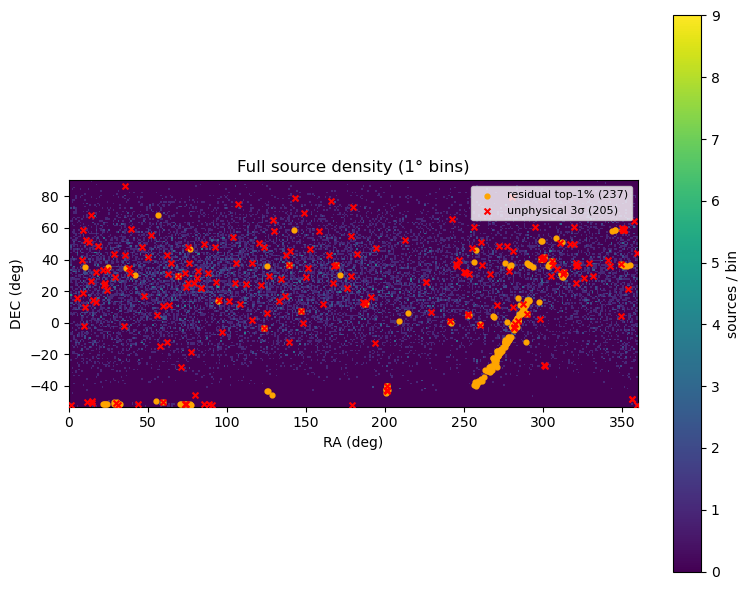


Fit-quality roll-up:


,band,n_sources,n_resid_top1,n_unphysical_3sig,max_bin_count,n_resid_and_unphysical
0,Full,15452,237,205,9,23
1,Blue,28976,417,214,16,86
2,Green,15797,262,69,8,29
3,Red,6268,92,19,4,11


In [11]:
import matplotlib.pyplot as plt

# Full-band 1° density map + flagged overlays; roll-up for all bands
primary_band = "Full" if "Full" in lst_merged else COLOR_BANDS[0]
df_full = lst_merged[primary_band]
H, ra_edges, dec_edges = sky_density_histogram(df_full, bin_deg=DENSITY_BIN_DEG)
top_bins = densest_bins(H, ra_edges, dec_edges, n=10)
print(f"Densest {DENSITY_BIN_DEG:g}° bins ({primary_band}):")
display(top_bins)

if H.size:
    fig, ax = plt.subplots(figsize=(8, 6))
    # H is (n_ra, n_dec); pcolormesh expects X,Y as edges
    mesh = ax.pcolormesh(ra_edges, dec_edges, H.T, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label="sources / bin")
    qa = fit_qa.get(primary_band, {})
    high = qa.get("high_residual", pd.Series(False, index=df_full.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df_full.index))
    if high.any():
        ax.scatter(
            df_full.loc[high, "RA"],
            df_full.loc[high, "DEC"],
            s=12,
            c="orange",
            marker="o",
            label=f"residual top-1% ({int(high.sum())})",
            zorder=3,
        )
    if unphys.any():
        ax.scatter(
            df_full.loc[unphys, "RA"],
            df_full.loc[unphys, "DEC"],
            s=18,
            c="red",
            marker="x",
            label=f"unphysical 3σ ({int(unphys.sum())})",
            zorder=4,
        )
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("DEC (deg)")
    ax.set_title(f"{primary_band} source density ({DENSITY_BIN_DEG:g}° bins)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print(f"No finite RA/DEC for density map ({primary_band}).")

# Roll-up summary across bands
rows = []
for band in COLOR_BANDS:
    df = lst_merged[band]
    qa = fit_qa.get(band, {})
    H_b, _, _ = sky_density_histogram(df, bin_deg=DENSITY_BIN_DEG)
    max_bin = int(H_b.max()) if H_b.size else 0
    high = qa.get("high_residual", pd.Series(False, index=df.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df.index))
    rows.append(
        {
            "band": band,
            "n_sources": int(len(df)),
            "n_resid_top1": int(qa.get("n_resid_top1", high.sum())),
            "n_unphysical_3sig": int(qa.get("n_unphysical_3sig", unphys.sum())),
            "max_bin_count": max_bin,
            "n_resid_and_unphysical": int((high & unphys).sum()),
        }
    )

fit_qa_summary = pd.DataFrame(rows)
print("\nFit-quality roll-up:")
display(fit_qa_summary)


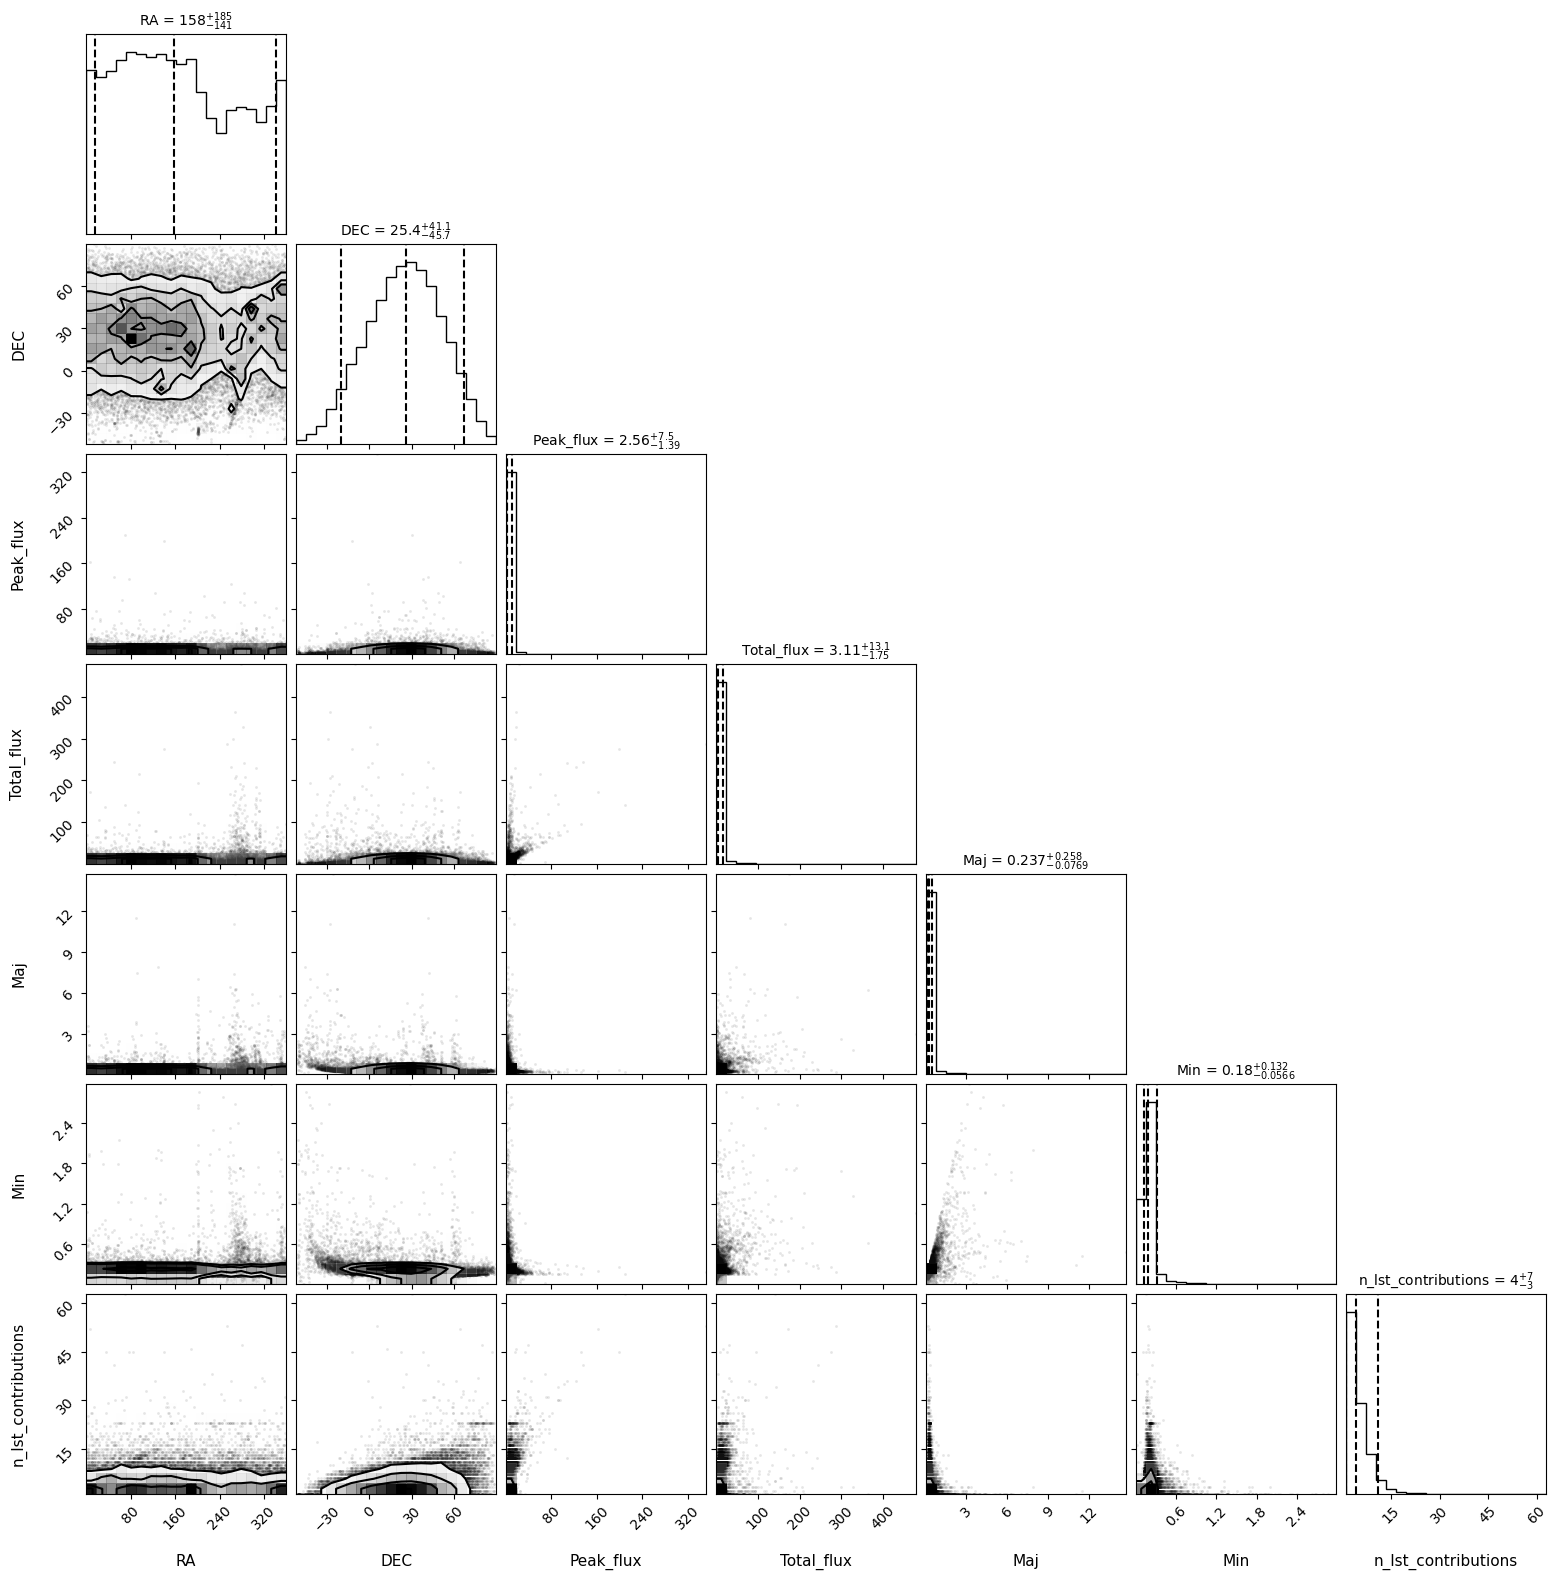

In [12]:
import corner
import matplotlib.pyplot as plt

cols = ["RA", "DEC", "Peak_flux", "Total_flux", "Maj", "Min", "n_lst_contributions"]

# drop NaNs; corner needs a clean numeric array
data = metacatalog[cols].dropna().to_numpy()

fig = corner.corner(
    data,
    labels=cols,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 11},
)

# Save before show — Cursor/VS Code often cannot "download" inline plot images.
#OUT_PNG = OUTPUT_DIR / "metacatalog_corner.png"
#fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
#print(f"Wrote {OUT_PNG}")
plt.show()


## Spectral index distribution

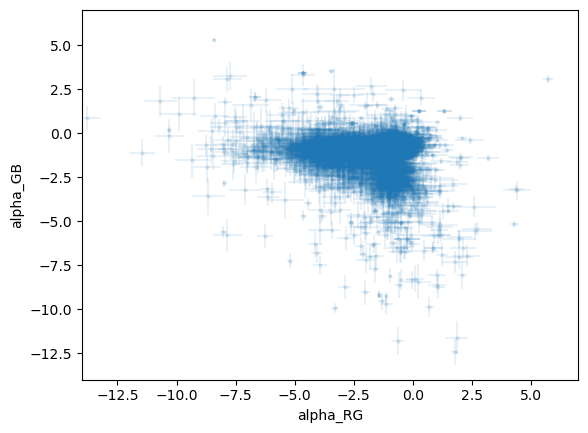

In [13]:
cols = ['meta_id', 'alpha_RG', 'E_alpha_RG', 'alpha_GB', 'E_alpha_GB']
data = metacatalog[cols].dropna(how='any')
ax = data.plot(x='alpha_RG', y='alpha_GB', xerr='E_alpha_RG', yerr='E_alpha_GB', marker='.', kind='scatter',
               alpha=0.1, xlim=[-14,7], ylim=[-14,7])
OUT_PNG = OUTPUT_DIR / "metacatalog_alpha.png"
ax.figure.savefig(OUT_PNG, dpi=150, bbox_inches="tight")

In [14]:
meta_ids = data[(data['alpha_RG']>1) & (data['alpha_GB']<-2)]['meta_id']

In [15]:
metacatalog.set_index('meta_id').loc[meta_ids].reset_index()

,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,n_assoc_Red,BMAJ_full,source_file_Full,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,927,Full,"Full,Blue,Green,Red",272.732266,-18.556763,12.175217,86.241057,0.935471,0.544334,18.048322,...,1,0.233604,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,4.387868,0.310696,-3.181260,0.210576
1,1912,Full,"Full,Blue,Green,Red",285.799238,5.669353,8.418941,207.234881,1.390315,0.845346,11.127541,...,2,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,4.300940,0.192766,-5.141233,0.161741
2,2543,Full,"Full,Blue,Green,Red",187.265620,12.603088,7.265366,28.062815,1.110634,0.308678,44.409843,...,2,0.230177,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.088380,0.266835,-8.760073,0.620931
3,2786,Full,"Full,Blue,Green,Red",260.583944,-0.666438,6.872635,19.027654,1.434658,0.940451,121.704661,...,1,0.230273,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,4.394824,0.572793,-3.253003,0.529341
4,3116,Full,"Full,Blue,Green,Red",1.389102,72.235295,6.451149,26.661170,0.542226,0.359647,89.692430,...,1,0.226296,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.706299,0.309238,-4.149580,0.227622
5,3263,Full,"Full,Blue,Green,Red",201.800588,-42.646781,6.285539,53.256224,1.625261,1.257495,33.865359,...,1,0.226635,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.778307,0.156801,-12.447583,0.729655
6,15543,Blue,"Blue,Green,Red",326.417506,36.436991,4.951383,27.261253,NaN,0.148111,174.386566,...,1,NaN,NaN,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.497212,0.121852,-4.410463,0.096971
7,4966,Full,"Full,Blue,Green,Red",241.721455,15.745255,4.943055,11.549748,0.419184,0.222880,32.965448,...,1,0.229482,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.053885,0.576726,-5.758696,0.548045
8,6203,Full,"Full,Blue,Green,Red",280.393018,-7.257790,4.328839,4.806439,0.264111,0.232410,56.653423,...,1,0.234924,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,2.729710,0.647975,-5.431330,0.370816
9,6256,Full,"Full,Blue,Green,Red",337.539457,25.186200,4.305077,13.524873,0.469775,0.260216,81.123443,...,1,0.230273,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.966232,0.531803,-5.910756,0.372411
